In [1]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    download = True,
)

test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor(),
    download = True,
)

In [3]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [4]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [5]:
train_data.data

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [6]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [7]:
from torch.utils.data import DataLoader

loaders = {
    'train': DataLoader(train_data,
                        batch_size=100,
                        shuffle=True,
                        num_workers=1),
    'test': DataLoader(test_data,
                       batch_size=100,
                       shuffle=True,
                       num_workers=1),
}

In [8]:
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x212b5972900>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x212b5975450>}

In [9]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)

        return F.softmax(x)

In [10]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss()

def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 20 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(loaders["train"].dataset)} ({100. * batch_idx / len(loaders["train"]):.0f}%)]\t{loss.item():.6f}')

def test():
    model.eval()

    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(loaders['test'].dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy {correct}/{len(loaders["test"].dataset)} ({100. * correct / len(loaders["test"].dataset):.0f}%\n)')

In [11]:
for epoch in range(1, 11):
    train(epoch)
    test()

C:\Users\Alex\AppData\Local\Temp\ipykernel_11152\3936228094.py:24: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


Train Epoch: 1 [0/60000 (0%)]	2.302621
Train Epoch: 1 [2000/60000 (3%)]	2.271871
Train Epoch: 1 [4000/60000 (7%)]	2.187451
Train Epoch: 1 [6000/60000 (10%)]	1.940981
Train Epoch: 1 [8000/60000 (13%)]	1.883389
Train Epoch: 1 [10000/60000 (17%)]	1.902892
Train Epoch: 1 [12000/60000 (20%)]	1.778427
Train Epoch: 1 [14000/60000 (23%)]	1.780852
Train Epoch: 1 [16000/60000 (27%)]	1.724593
Train Epoch: 1 [18000/60000 (30%)]	1.705198
Train Epoch: 1 [20000/60000 (33%)]	1.741042
Train Epoch: 1 [22000/60000 (37%)]	1.694845
Train Epoch: 1 [24000/60000 (40%)]	1.708260
Train Epoch: 1 [26000/60000 (43%)]	1.714238
Train Epoch: 1 [28000/60000 (47%)]	1.722646
Train Epoch: 1 [30000/60000 (50%)]	1.680565
Train Epoch: 1 [32000/60000 (53%)]	1.671138
Train Epoch: 1 [34000/60000 (57%)]	1.623615
Train Epoch: 1 [36000/60000 (60%)]	1.649255
Train Epoch: 1 [38000/60000 (63%)]	1.621922
Train Epoch: 1 [40000/60000 (67%)]	1.621088
Train Epoch: 1 [42000/60000 (70%)]	1.636178
Train Epoch: 1 [44000/60000 (73%)]	1.657345

In [12]:
device

device(type='cpu')

Prediction: 5, Target: 5


C:\Users\Alex\AppData\Local\Temp\ipykernel_11152\3936228094.py:24: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


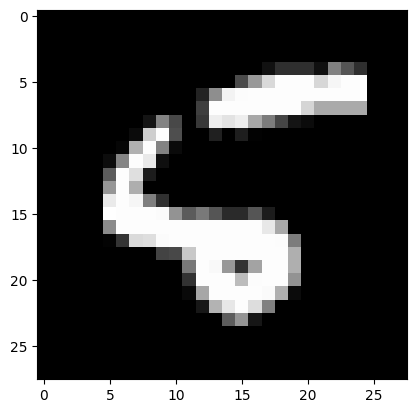

In [13]:
import matplotlib.pyplot as plt

model.eval()

data, target = test_data[8]

data = data.unsqueeze(0).to(device)

output = model(data)

prediction = output.argmax(dim=1, keepdim=True).item()

print(f'Prediction: {prediction}, Target: {target}')

image = data.squeeze(0).squeeze(0).cpu().numpy()

plt.imshow(image, cmap='gray')
plt.show()

In [14]:
import torch
import onnx

model.eval()

dummy_input = torch.randn(1, 1, 28, 28).to(device)

torch.onnx.export(
    model,
    dummy_input,
    'cnn.onnx',
    input_names=['input'],
    output_names=['output'],
)

[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...


C:\Users\Alex\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\_export\non_strict_utils.py:1167: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return func(*args, **kwargs)


[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


C:\Users\Alex\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.12.1+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,1,28,28]>
            ),
            outputs=(
                %"output"<FLOAT,[1,10]>
            ),
            initializers=(
                %"conv1.weight"<FLOAT,[10,1,5,5]>{TorchTensor(...)},
                %"conv1.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([ 0.0348, -0.0408, -0.2379, -0.0027, -0.0522,  0.0024,  0.2783,  0.4092, 0.1247, -0.0744], requires_grad=True), name='conv1.bias')},
                %"conv2.weight"<FLOAT,[20,10,5,5]>{TorchTensor(...)},
                %"conv2.bias"<FLOAT,[20]>{TorchTensor(...)},
                %"fc1.weight"<FLOAT,[50,320]>{TorchTensor(...)},
                %"fc1.bias"<FLOAT,[